# 03 — Coefficients and model diagnostics

This notebook visualizes frequentist coefficients, Bayesian posterior summaries, and sampling diagnostics. It helps separate stable model signals from uncertain or weak effects.

In [1]:

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# This lets the notebook work whether it is launched from the project root or from notebooks/.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUTS = PROJECT_ROOT / "outputs"
FIGURES = OUTPUTS / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)


def read_json(path):
    path = Path(path)
    if not path.exists():
        return {}
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def require_file(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing expected file: {path}")
    return path


def load_csv(relative_path, **kwargs):
    path = require_file(OUTPUTS / relative_path)
    return pd.read_csv(path, **kwargs)


def savefig(name):
    path = FIGURES / name
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    print(f"Saved figure: {path}")

print(f"Project root: {PROJECT_ROOT}")
print(f"Outputs folder: {OUTPUTS}")


Project root: c:\Users\zacwr\OneDrive\XD\Projects\math-seminar\sana_project
Outputs folder: c:\Users\zacwr\OneDrive\XD\Projects\math-seminar\sana_project\outputs


## Frequentist coefficient table

In [2]:

summary = load_csv("model_summary.csv")
summary.head(20)


,term,coef,std_err,z,p_value,model_type,ci_lower,ci_upper,exp_coef,note
0,const,-7.033295,0.050517,-139.226381,0.000000,discrete_negative_binomial_estimated_dispersion,-7.132306,-6.934283,0.000882,NaN
1,ambientalagua_kernel_intensity,0.033356,0.356739,0.093501,0.925505,discrete_negative_binomial_estimated_dispersion,-0.665841,0.732552,1.033918,coef is per 1 SD increase in standardized feature
2,ambientalagua_nearest_source_m,-0.388797,0.152163,-2.555138,0.010615,discrete_negative_binomial_estimated_dispersion,-0.687030,-0.090563,0.677872,coef is per 1 SD increase in standardized feature
3,ambientalagua_count_within_10000m,-0.172118,0.136682,-1.259261,0.207936,discrete_negative_binomial_estimated_dispersion,-0.440010,0.095773,0.841880,coef is per 1 SD increase in standardized feature
4,ambientalladrilleras_kernel_intensity,0.130647,0.133768,0.976665,0.328735,discrete_negative_binomial_estimated_dispersion,-0.131534,0.392828,1.139565,coef is per 1 SD increase in standardized feature
5,ambientalladrilleras_nearest_source_m,0.111579,0.101940,1.094549,0.273714,discrete_negative_binomial_estimated_dispersion,-0.088221,0.311378,1.118042,coef is per 1 SD increase in standardized feature
6,ambientalminasmetales_kernel_intensity,-0.121966,0.091424,-1.334060,0.182184,discrete_negative_binomial_estimated_dispersion,-0.301154,0.057223,0.885179,coef is per 1 SD increase in standardized feature
7,ambientalminasmetales_nearest_source_m,-0.041582,0.150892,-0.275573,0.782876,discrete_negative_binomial_estimated_dispersion,-0.337324,0.254161,0.959271,coef is per 1 SD increase in standardized feature
8,ambientalretc_kernel_intensity,-0.307729,0.186116,-1.653426,0.098244,discrete_negative_binomial_estimated_dispersion,-0.672510,0.057052,0.735114,coef is per 1 SD increase in standardized feature
9,ambientalretc_nearest_source_m,-0.073960,0.062841,-1.176935,0.239221,discrete_negative_binomial_estimated_dispersion,-0.197125,0.049206,0.928709,coef is per 1 SD increase in standardized feature


Saved figure: c:\Users\zacwr\OneDrive\XD\Projects\math-seminar\sana_project\outputs\figures\03_frequentist_coefficients.png


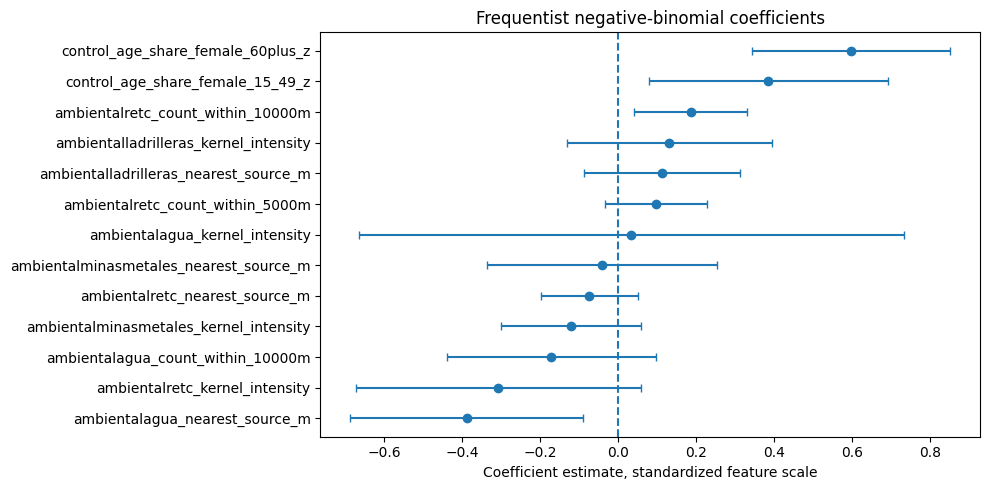

In [3]:

coef_df = summary[summary["term"].ne("const")].copy()
coef_df = coef_df[coef_df["term"].ne("alpha")]
coef_df = coef_df.dropna(subset=["coef", "ci_lower", "ci_upper"])
coef_df = coef_df.sort_values("coef")

fig, ax = plt.subplots(figsize=(10, max(5, len(coef_df) * 0.35)))
x = coef_df["coef"]
xerr = np.vstack([x - coef_df["ci_lower"], coef_df["ci_upper"] - x])
ax.errorbar(x, coef_df["term"], xerr=xerr, fmt="o", capsize=3)
ax.axvline(0, linestyle="--")
ax.set_xlabel("Coefficient estimate, standardized feature scale")
ax.set_title("Frequentist negative-binomial coefficients")
savefig("03_frequentist_coefficients.png")
plt.show()


## Bayesian trace summaries

In [4]:

nb_summary = load_csv("bayes/bayesian_trace_summary.csv")
spatial_summary = load_csv("bayes_spatial/bayesian_spatial_trace_summary.csv")
print("Non-spatial Bayesian summary shape:", nb_summary.shape)
print("Spatial Bayesian summary shape:", spatial_summary.shape)
spatial_summary.head()


Non-spatial Bayesian summary shape: (15, 10)
Spatial Bayesian summary shape: (17, 10)


,Unnamed: 0,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
0,intercept,-7.027,0.078,-7.169,-6.882,0.001,0.002,3043.0,1478.0,1.0
1,beta[0],0.060,0.349,-0.613,0.687,0.009,0.007,1476.0,1276.0,1.0
2,beta[1],-0.312,0.207,-0.710,0.069,0.007,0.004,962.0,1197.0,1.0
3,beta[2],-0.070,0.170,-0.381,0.243,0.005,0.004,1378.0,1239.0,1.0
4,beta[3],0.073,0.194,-0.263,0.457,0.005,0.004,1579.0,1462.0,1.0


## Map Bayesian parameter names back to features and controls

In [5]:

nb_config = read_json(OUTPUTS / "bayesian_model_config.json")
spatial_config = read_json(OUTPUTS / "bayesian_spatial_model_config.json")

feature_cols = spatial_config.get("feature_cols", nb_config.get("feature_cols", []))
control_cols = spatial_config.get("control_cols", nb_config.get("control_cols", []))

def label_param(name):
    text = str(name)
    if text.startswith("beta["):
        idx = int(text.split("[")[1].split("]")[0])
        return feature_cols[idx] if idx < len(feature_cols) else text
    if text.startswith("gamma["):
        idx = int(text.split("[")[1].split("]")[0])
        return control_cols[idx] if idx < len(control_cols) else text
    return text

spatial_summary["label"] = spatial_summary[spatial_summary.columns[0]].apply(label_param)
nb_summary["label"] = nb_summary[nb_summary.columns[0]].apply(label_param)

spatial_summary[[spatial_summary.columns[0], "label", "mean", "sd", "hdi_3%", "hdi_97%", "ess_bulk", "r_hat"]].head(30)


,Unnamed: 0,label,mean,sd,hdi_3%,hdi_97%,ess_bulk,r_hat
0,intercept,intercept,-7.027,0.078,-7.169,-6.882,3043.0,1.0
1,beta[0],ambientalagua_kernel_intensity,0.060,0.349,-0.613,0.687,1476.0,1.0
2,beta[1],ambientalagua_nearest_source_m,-0.312,0.207,-0.710,0.069,962.0,1.0
3,beta[2],ambientalagua_count_within_10000m,-0.070,0.170,-0.381,0.243,1378.0,1.0
4,beta[3],ambientalladrilleras_kernel_intensity,0.073,0.194,-0.263,0.457,1579.0,1.0
5,beta[4],ambientalladrilleras_nearest_source_m,0.108,0.158,-0.187,0.401,1268.0,1.0
6,beta[5],ambientalminasmetales_kernel_intensity,-0.107,0.133,-0.351,0.150,1114.0,1.0
7,beta[6],ambientalminasmetales_nearest_source_m,-0.042,0.217,-0.440,0.359,933.0,1.0
8,beta[7],ambientalretc_kernel_intensity,-0.230,0.209,-0.612,0.159,1563.0,1.0
9,beta[8],ambientalretc_nearest_source_m,-0.044,0.103,-0.242,0.139,2168.0,1.0


## Bayesian spatial exposure/control posteriors

Saved figure: c:\Users\zacwr\OneDrive\XD\Projects\math-seminar\sana_project\outputs\figures\03_bayesian_spatial_coefficients.png


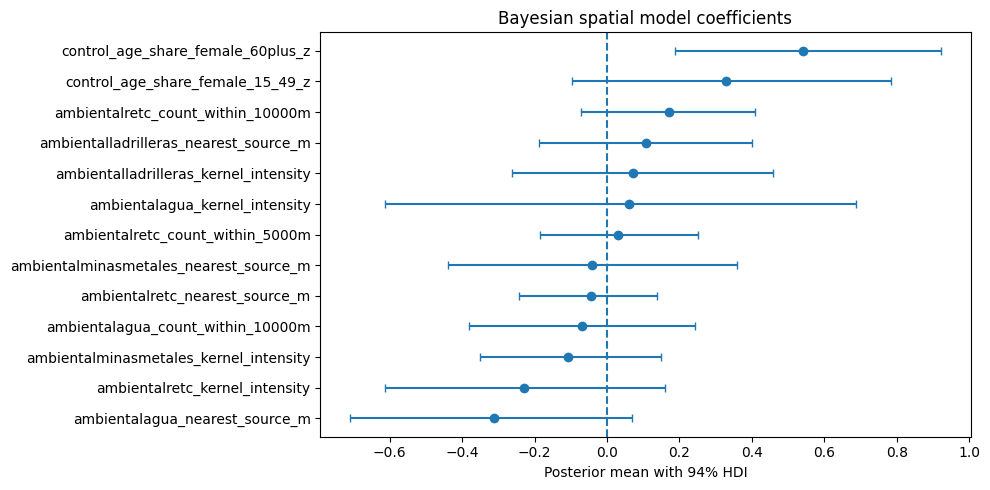

In [6]:

name_col = spatial_summary.columns[0]
param_df = spatial_summary[spatial_summary[name_col].astype(str).str.startswith(("beta[", "gamma["))].copy()
param_df = param_df.sort_values("mean")

fig, ax = plt.subplots(figsize=(10, max(5, len(param_df) * 0.35)))
x = param_df["mean"]
xerr = np.vstack([x - param_df["hdi_3%"], param_df["hdi_97%"] - x])
ax.errorbar(x, param_df["label"], xerr=xerr, fmt="o", capsize=3)
ax.axvline(0, linestyle="--")
ax.set_xlabel("Posterior mean with 94% HDI")
ax.set_title("Bayesian spatial model coefficients")
savefig("03_bayesian_spatial_coefficients.png")
plt.show()


## Sampling diagnostics

In [7]:

status_nb = read_json(OUTPUTS / "bayes/bayesian_output_status.json")
status_spatial = read_json(OUTPUTS / "bayes_spatial/bayesian_spatial_model_status.json")

diagnostics = pd.DataFrame([
    {"model": "Bayesian NB", **status_nb},
    {"model": "Bayesian spatial hierarchical NB", **status_spatial},
])
# Show only compact diagnostic columns if present.
cols = ["model", "fit_completed", "draws", "tune", "chains", "divergences", "mean_acceptance_rate", "max_tree_depth", "n_likelihood_rows", "n_prediction_rows"]
cols = [c for c in cols if c in diagnostics.columns]
diagnostics[cols]


,model,fit_completed,draws,tune,chains,divergences,mean_acceptance_rate,max_tree_depth,n_likelihood_rows,n_prediction_rows
0,Bayesian NB,True,1000,1000,2,0,0.908234,7,57,58
1,Bayesian spatial hierarchical NB,True,1000,1000,2,0,0.920435,6,57,58


In [8]:

# Focus on any parameters with high R-hat or low ESS.
for label, df0 in [("non_spatial", nb_summary), ("spatial", spatial_summary)]:
    if "r_hat" in df0.columns:
        flagged = df0[(df0["r_hat"] > 1.01) | (df0.get("ess_bulk", pd.Series(np.inf, index=df0.index)) < 400)]
        print(label, "flagged parameters:", len(flagged))
        display(flagged.head(20))


non_spatial flagged parameters: 0


,Unnamed: 0,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,label


spatial flagged parameters: 0


,Unnamed: 0,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,label


## Optional: trace plots

Run this cell if you want visual trace diagnostics. It may take a moment because it loads the NetCDF trace files.

In [9]:

# Uncomment to inspect trace plots interactively.
# import arviz as az
# idata = az.from_netcdf(OUTPUTS / "bayes_spatial/bayesian_spatial_trace.nc")
# az.plot_trace(idata, var_names=["intercept", "structured_scale", "unstructured_scale", "overdispersion_alpha"])
# plt.show()
